# IMPORTS & LOAD FUNC

In [29]:
from pathlib import Path
from urllib import request
import pandas as pd
import matplotlib.pyplot as plt
from pandas.plotting import scatter_matrix
import numpy as np
import seaborn as sns
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from xgboost import XGBRegressor
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder, OrdinalEncoder
from sklearn.model_selection import cross_val_predict, cross_val_score, StratifiedShuffleSplit, GridSearchCV
from sklearn.metrics import r2_score, mean_squared_error, root_mean_squared_error, mean_absolute_error, accuracy_score, recall_score, precision_score, ConfusionMatrixDisplay
from sklearn.linear_model import LinearRegression, SGDRegressor, LogisticRegression
from sklearn.neighbors import KNeighborsClassifier



def downloadDf():
    requiredFile = Path("dataSet/adult_income.csv")
    if not requiredFile.is_file():
        Path("dataSet").mkdir(exist_ok=True)
        file_id = "1cCB19GQ3Of92RAk5TVb0DPohCt1eZR6d"
        download_url = f"https://drive.google.com/uc?export=download&id={file_id}"
        request.urlretrieve(download_url, requiredFile)
    return pd.read_csv(requiredFile)

# Q1

### Question 1: Exploratory Data Analysis (EDA) -20
Problem Statement:
Find the three most important factors that separate individuals who earn more than $50K annually from those who earn $50K or less.
Tasks:
Perform EDA using appropriate charts and basic descriptive statistics.
Select your top 3 features and justify your choices using visual and statistical evidence.
For each selected feature, explain in simple terms why it intuitively affects income.
Rank your 3 features from most important to least important, provide why you think that ?


,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,income
27159,50,Self-emp-inc,155574,Masters,14,Married-civ-spouse,Prof-specialty,Husband,White,Male,7298,0,50,United-States,>50K
20012,18,Private,133654,HS-grad,9,Never-married,Adm-clerical,Own-child,White,Female,0,0,40,United-States,<=50K
543,27,Private,163862,HS-grad,9,Never-married,Transport-moving,Not-in-family,White,Male,0,0,40,United-States,<=50K
28986,40,Private,367533,Some-college,10,Married-civ-spouse,Machine-op-inspct,Husband,White,Male,2580,0,40,United-States,<=50K
30928,37,Private,150057,HS-grad,9,Married-civ-spouse,Craft-repair,Husband,White,Male,0,0,52,United-States,>50K


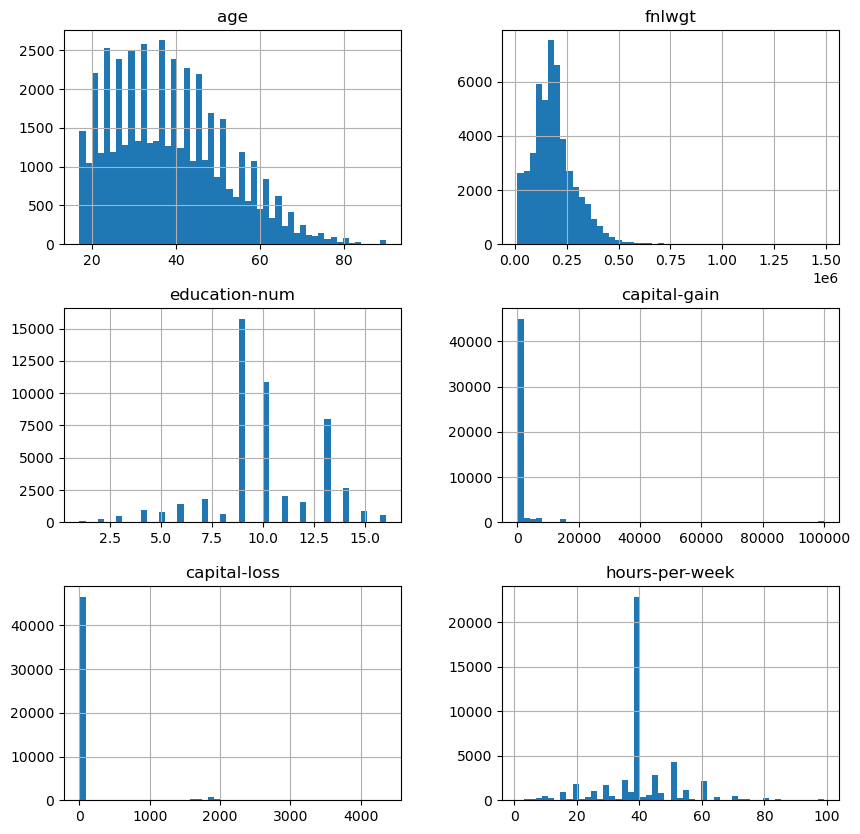

,age,fnlwgt,education-num,capital-gain,capital-loss,hours-per-week
count,48842.000000,4.884200e+04,48842.000000,48842.000000,48842.000000,48842.000000
mean,38.643585,1.896641e+05,10.078089,1079.067626,87.502314,40.422382
std,13.710510,1.056040e+05,2.570973,7452.019058,403.004552,12.391444
min,17.000000,1.228500e+04,1.000000,0.000000,0.000000,1.000000
25%,28.000000,1.175505e+05,9.000000,0.000000,0.000000,40.000000
50%,37.000000,1.781445e+05,10.000000,0.000000,0.000000,40.000000
75%,48.000000,2.376420e+05,12.000000,0.000000,0.000000,45.000000
max,90.000000,1.490400e+06,16.000000,99999.000000,4356.000000,99.000000


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48842 entries, 0 to 48841
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   age             48842 non-null  int64 
 1   workclass       48842 non-null  object
 2   fnlwgt          48842 non-null  int64 
 3   education       48842 non-null  object
 4   education-num   48842 non-null  int64 
 5   marital-status  48842 non-null  object
 6   occupation      48842 non-null  object
 7   relationship    48842 non-null  object
 8   race            48842 non-null  object
 9   sex             48842 non-null  object
 10  capital-gain    48842 non-null  int64 
 11  capital-loss    48842 non-null  int64 
 12  hours-per-week  48842 non-null  int64 
 13  native-country  48842 non-null  object
 14  income          48842 non-null  object
dtypes: int64(6), object(9)
memory usage: 5.6+ MB


In [30]:
rawDF = downloadDf()
display(rawDF.sample(5))
rawDF.hist(figsize=(10,10), bins=50)
plt.show()
display(rawDF.describe())
rawDF.info()

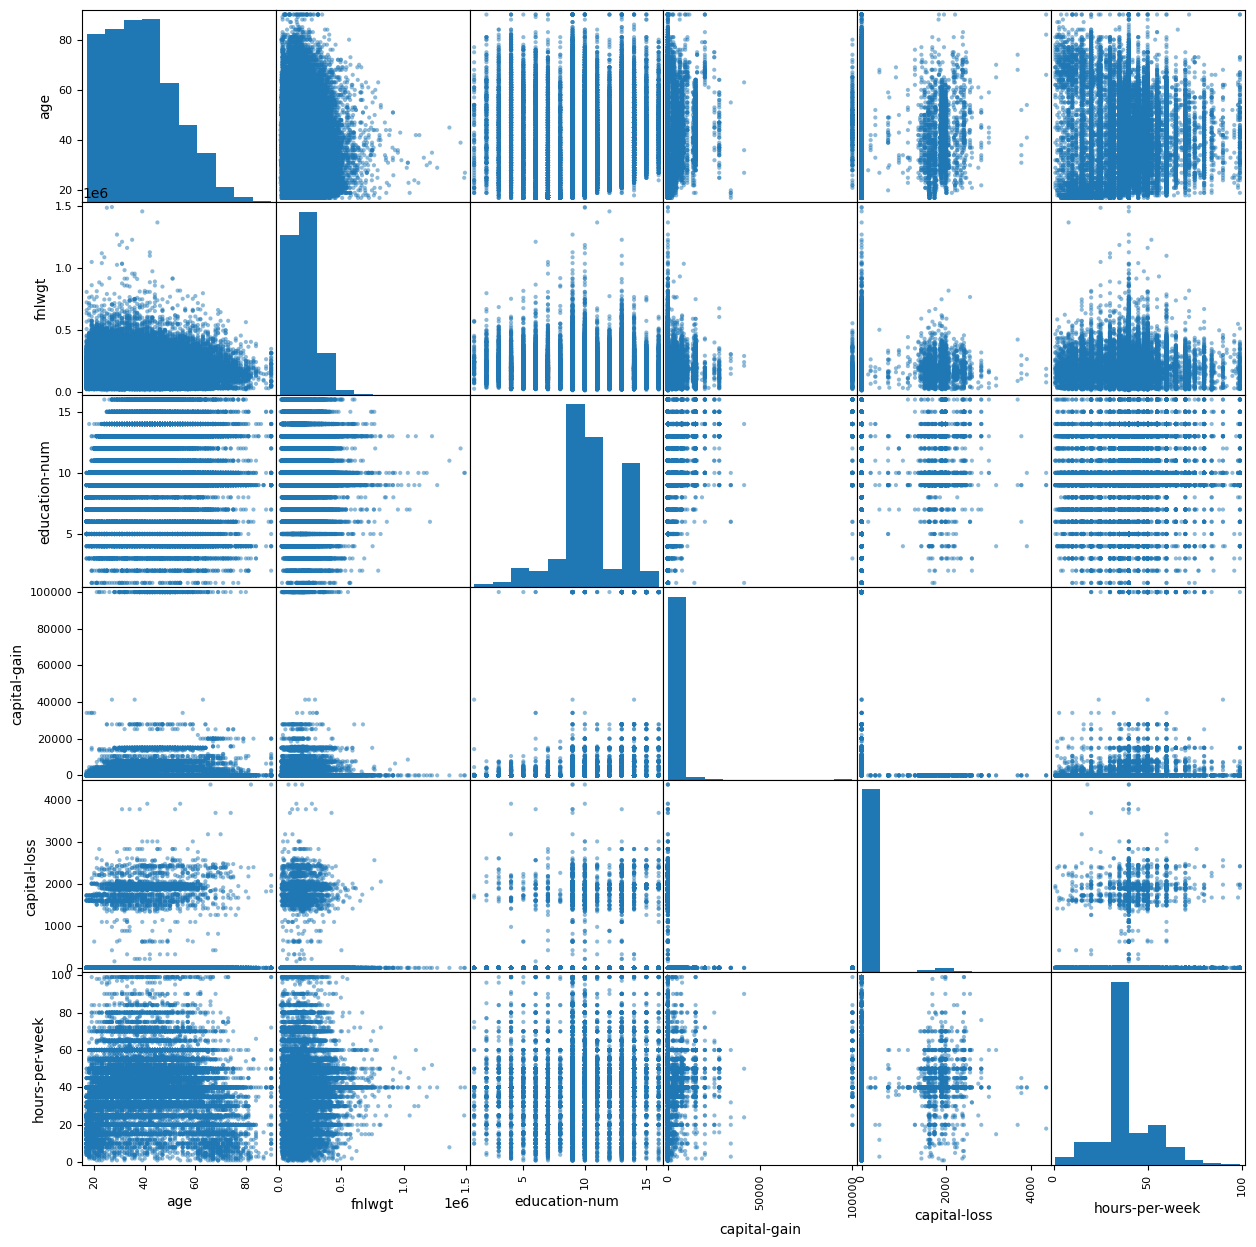

In [31]:
scatter_matrix(rawDF.select_dtypes(include=np.number), figsize=(15, 15))
plt.show()

<Axes: xlabel='income', ylabel='count'>

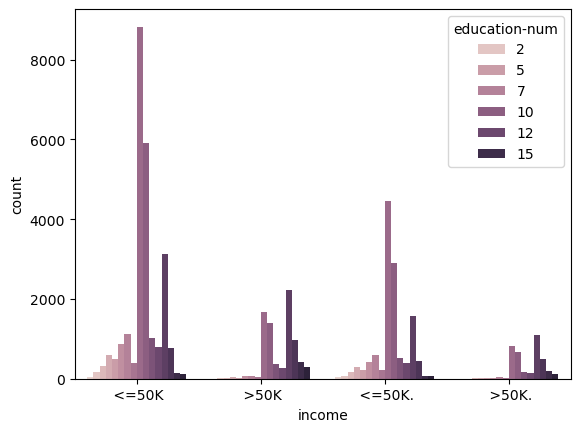

In [32]:
sns.countplot(data=rawDF, x="income", hue="education-num")

<Axes: xlabel='income', ylabel='count'>

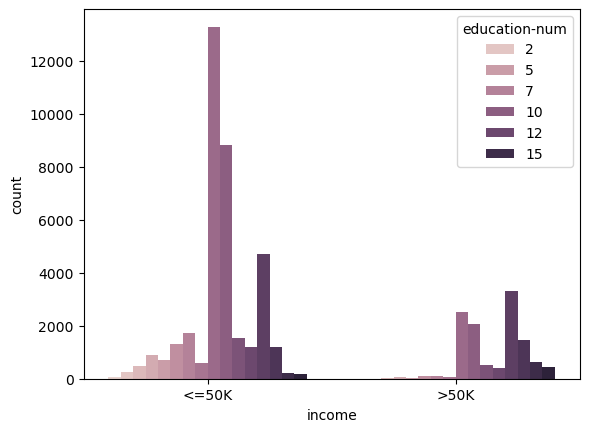

In [33]:
rawDF["income"] = rawDF["income"].str.strip().str.replace(".", "", regex=False)
sns.countplot(data=rawDF, x="income", hue="education-num")

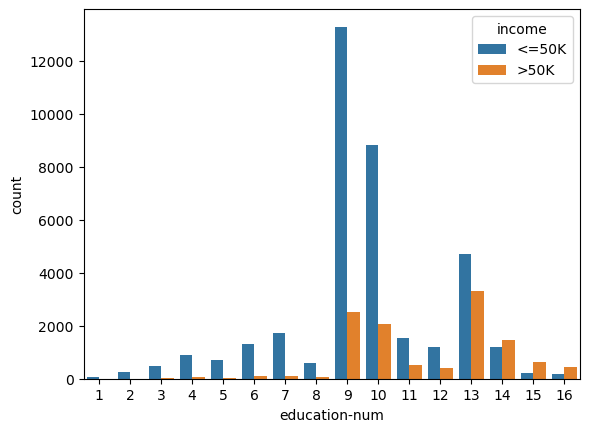

education-num  income
1              <=50K     0.987952
               >50K      0.012048
2              <=50K     0.967611
               >50K      0.032389
3              <=50K     0.946955
               >50K      0.053045
4              <=50K     0.935079
               >50K      0.064921
5              <=50K     0.945767
               >50K      0.054233
6              <=50K     0.937365
               >50K      0.062635
7              <=50K     0.949227
               >50K      0.050773
8              <=50K     0.926941
               >50K      0.073059
9              <=50K     0.841422
               >50K      0.158578
10             <=50K     0.810351
               >50K      0.189649
11             <=50K     0.746725
               >50K      0.253275
12             <=50K     0.742036
               >50K      0.257964
13             <=50K     0.587165
               >50K      0.412835
14             >50K      0.549116
               <=50K     0.450884
15             >50K      0

In [34]:
sns.countplot(data=rawDF, x="education-num", hue="income")
plt.show()
rawDF[["education-num", "income"]].groupby("education-num").value_counts(normalize=True)

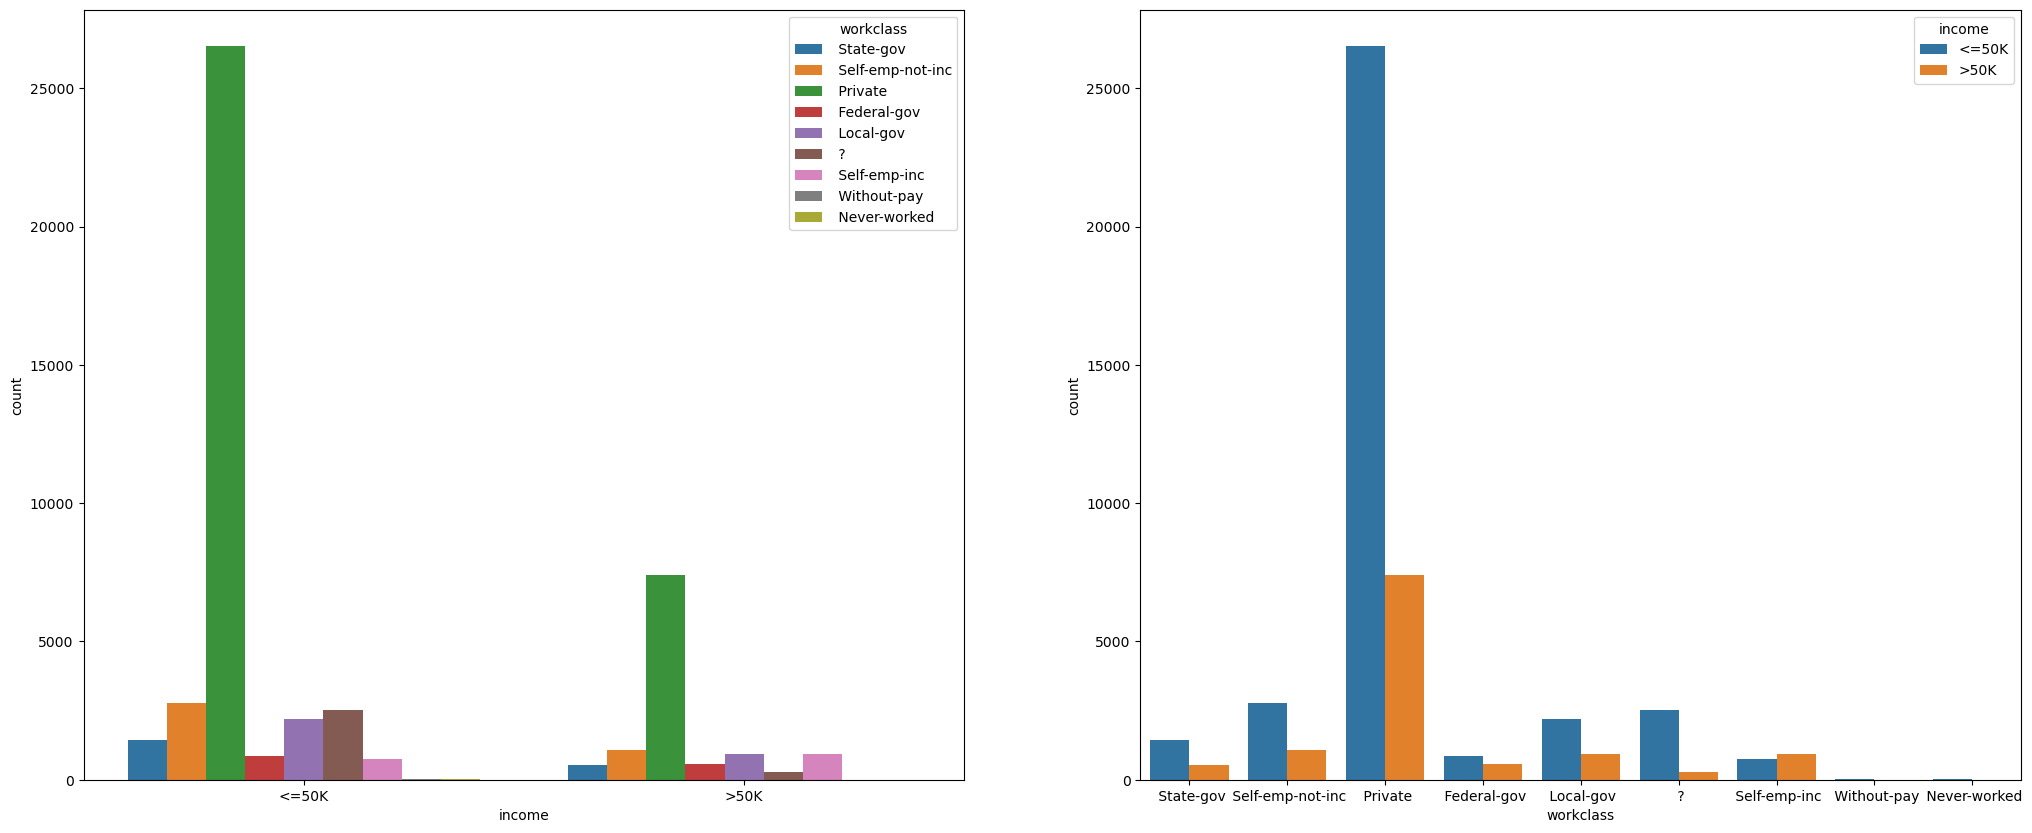

workclass         income
?                 <=50K     0.905323
                  >50K      0.094677
Federal-gov       <=50K     0.608240
                  >50K      0.391760
Local-gov         <=50K     0.704401
                  >50K      0.295599
Never-worked      <=50K     1.000000
Private           <=50K     0.782133
                  >50K      0.217867
Self-emp-inc      >50K      0.553392
                  <=50K     0.446608
Self-emp-not-inc  <=50K     0.721129
                  >50K      0.278871
State-gov         <=50K     0.732458
                  >50K      0.267542
Without-pay       <=50K     0.904762
                  >50K      0.095238
Name: proportion, dtype: float64

In [35]:
plt.figure(figsize=(25,10))
plt.subplot(1, 2, 1)
sns.countplot(data=rawDF, x="income", hue="workclass")
plt.subplot(1, 2, 2)
sns.countplot(data=rawDF, x="workclass", hue="income")
plt.show()
rawDF[["workclass", "income"]].groupby("workclass").value_counts(normalize=True)

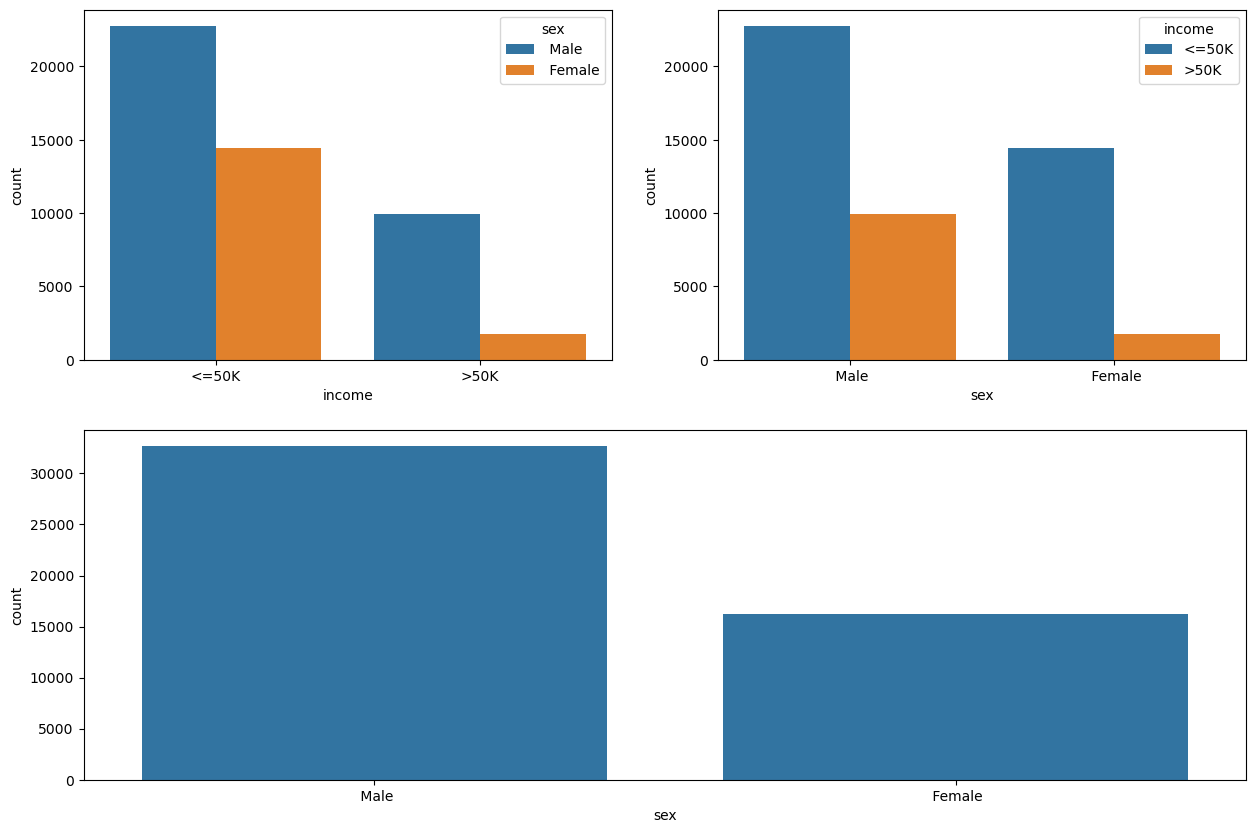

sex     income
Female  <=50K     0.890749
        >50K      0.109251
Male    <=50K     0.696233
        >50K      0.303767
Name: proportion, dtype: float64

In [36]:
plt.figure(figsize=(15,10))
plt.subplot(2, 2, 1)
sns.countplot(data=rawDF, x="income", hue="sex")
plt.subplot(2, 2, 2)
sns.countplot(data=rawDF, x="sex", hue="income")
plt.subplot(2, 1, 2)
sns.countplot(data=rawDF, x="sex")
plt.show()
rawDF[["sex", "income"]].groupby("sex").value_counts(normalize=True)

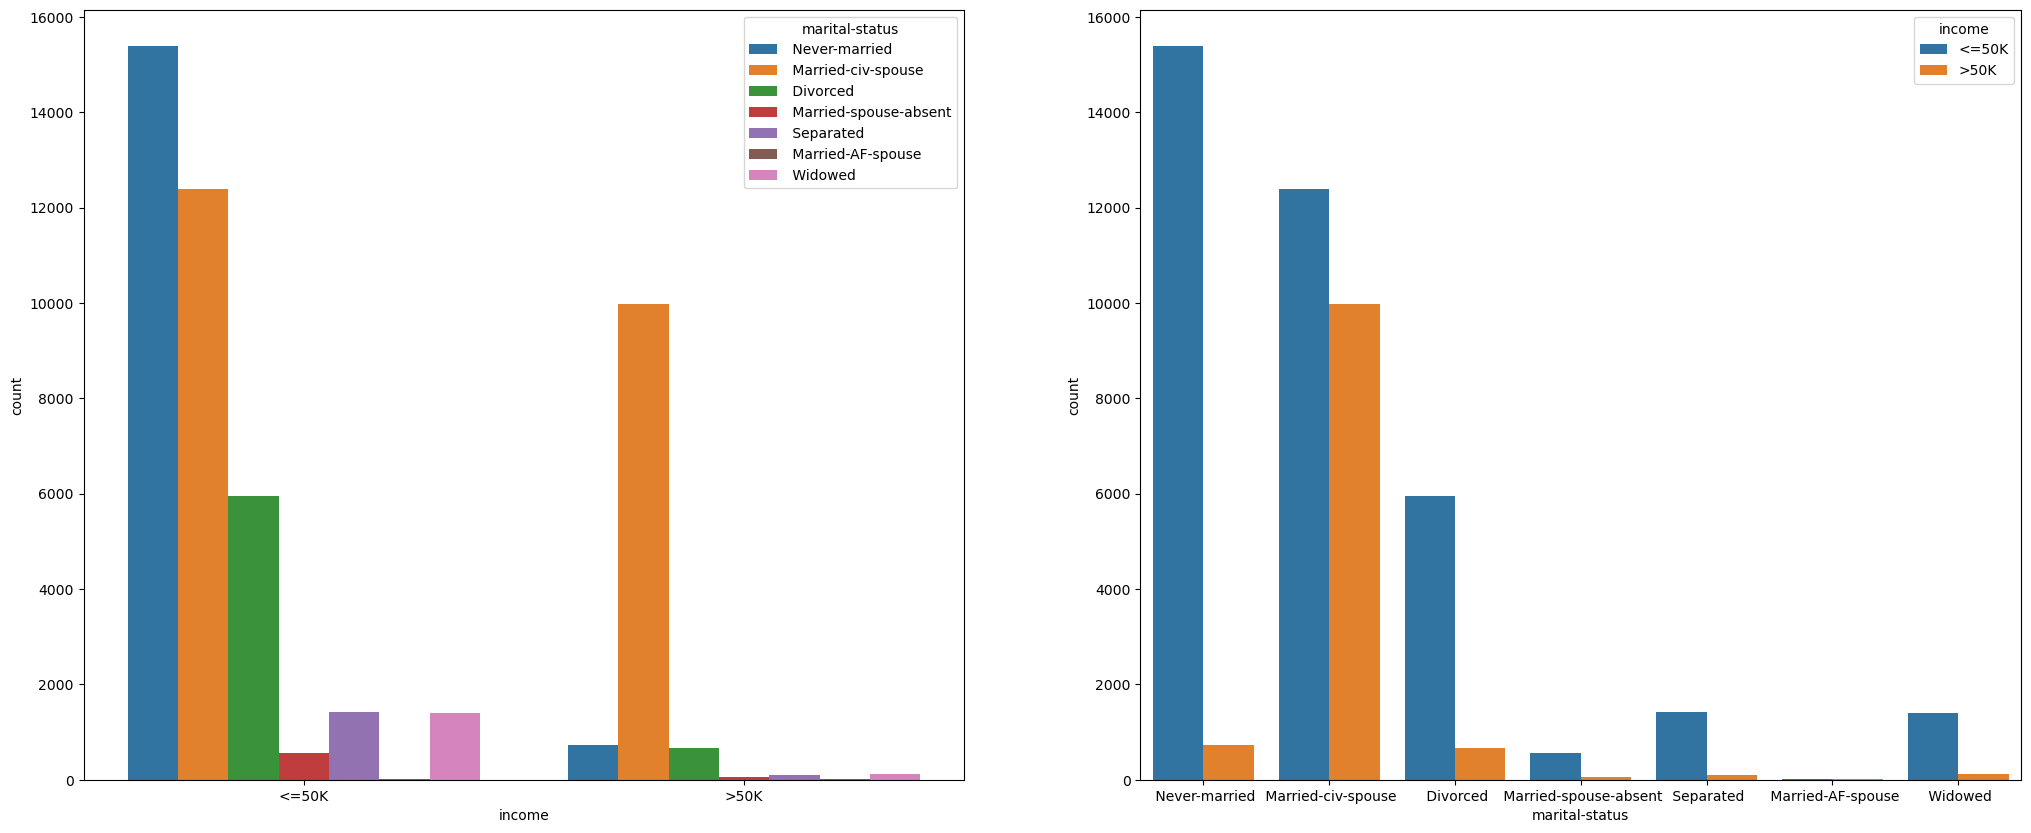

marital-status         income
Divorced               <=50K     0.898839
                       >50K      0.101161
Married-AF-spouse      <=50K     0.621622
                       >50K      0.378378
Married-civ-spouse     <=50K     0.553867
                       >50K      0.446133
Married-spouse-absent  <=50K     0.907643
                       >50K      0.092357
Never-married          <=50K     0.954520
                       >50K      0.045480
Separated              <=50K     0.935294
                       >50K      0.064706
Widowed                <=50K     0.915679
                       >50K      0.084321
Name: proportion, dtype: float64

In [37]:
plt.figure(figsize=(25,10))
plt.subplot(1, 2, 1)
sns.countplot(data=rawDF, x="income", hue="marital-status")
plt.subplot(1, 2, 2)
sns.countplot(data=rawDF, x="marital-status", hue="income")
plt.show()
rawDF[["marital-status", "income"]].groupby("marital-status").value_counts(normalize=True)

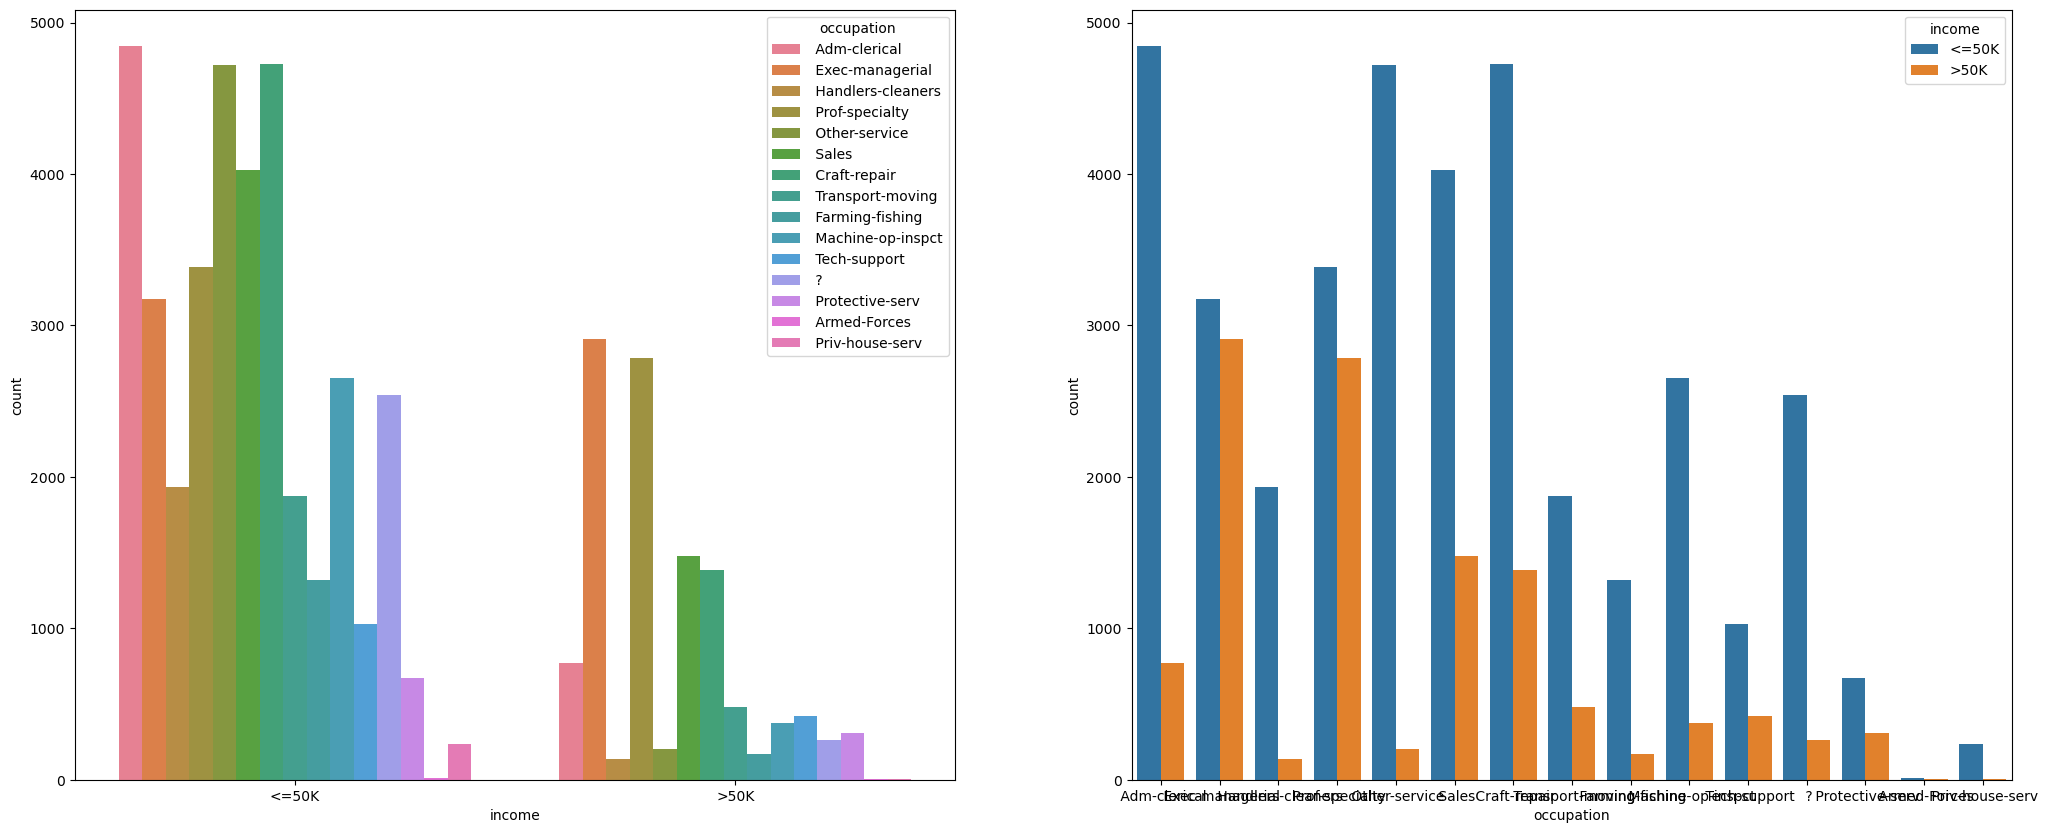

occupation         income
?                  <=50K     0.905660
                   >50K      0.094340
Adm-clerical       <=50K     0.863126
                   >50K      0.136874
Armed-Forces       <=50K     0.666667
                   >50K      0.333333
Craft-repair       <=50K     0.773724
                   >50K      0.226276
Exec-managerial    <=50K     0.522182
                   >50K      0.477818
Farming-fishing    <=50K     0.883893
                   >50K      0.116107
Handlers-cleaners  <=50K     0.933398
                   >50K      0.066602
Machine-op-inspct  <=50K     0.876903
                   >50K      0.123097
Other-service      <=50K     0.958562
                   >50K      0.041438
Priv-house-serv    <=50K     0.987603
                   >50K      0.012397
Prof-specialty     <=50K     0.548931
                   >50K      0.451069
Protective-serv    <=50K     0.686673
                   >50K      0.313327
Sales              <=50K     0.732013
                   >50K 

In [38]:
plt.figure(figsize=(25,10))
plt.subplot(1, 2, 1)
sns.countplot(data=rawDF, x="income", hue="occupation")
plt.subplot(1, 2, 2)
sns.countplot(data=rawDF, x="occupation", hue="income")
plt.show()
rawDF[["occupation", "income"]].groupby("occupation").value_counts(normalize=True)

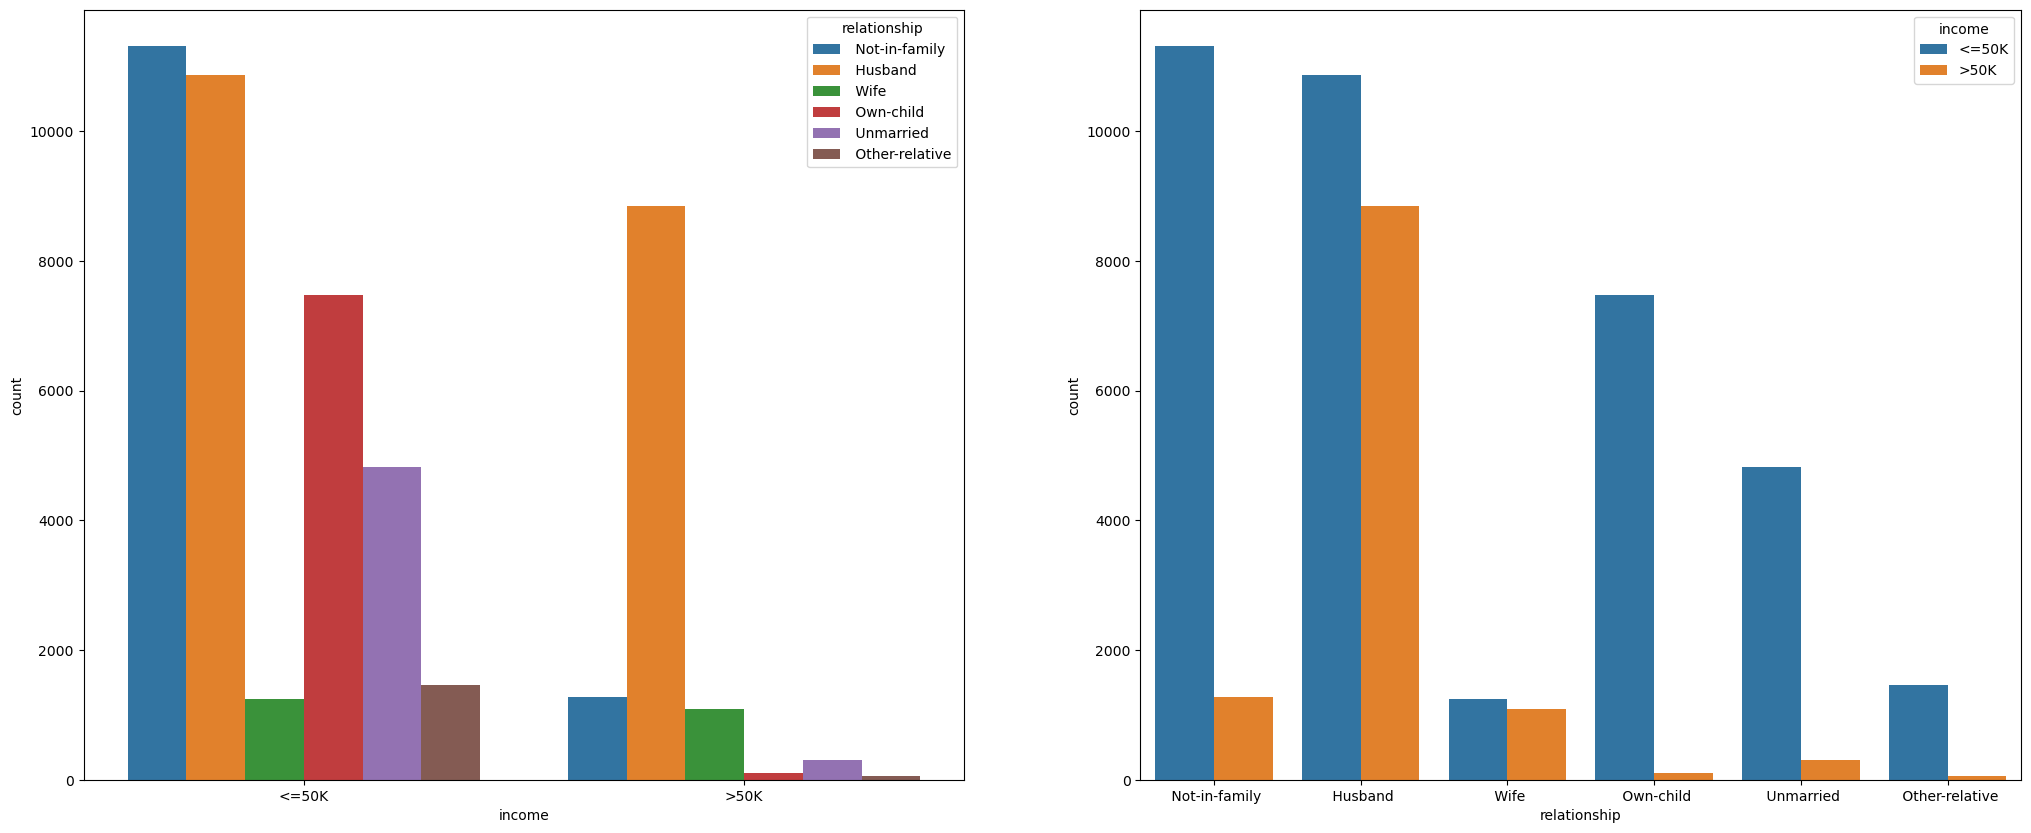

relationship    income
Husband         <=50K     0.551329
                >50K      0.448671
Not-in-family   <=50K     0.898593
                >50K      0.101407
Other-relative  <=50K     0.965471
                >50K      0.034529
Own-child       <=50K     0.985358
                >50K      0.014642
Unmarried       <=50K     0.939707
                >50K      0.060293
Wife            <=50K     0.531103
                >50K      0.468897
Name: proportion, dtype: float64

In [39]:
plt.figure(figsize=(25,10))
plt.subplot(1, 2, 1)
sns.countplot(data=rawDF, x="income", hue="relationship")
plt.subplot(1, 2, 2)
sns.countplot(data=rawDF, x="relationship", hue="income")
plt.show()
rawDF[["relationship", "income"]].groupby("relationship").value_counts(normalize=True)

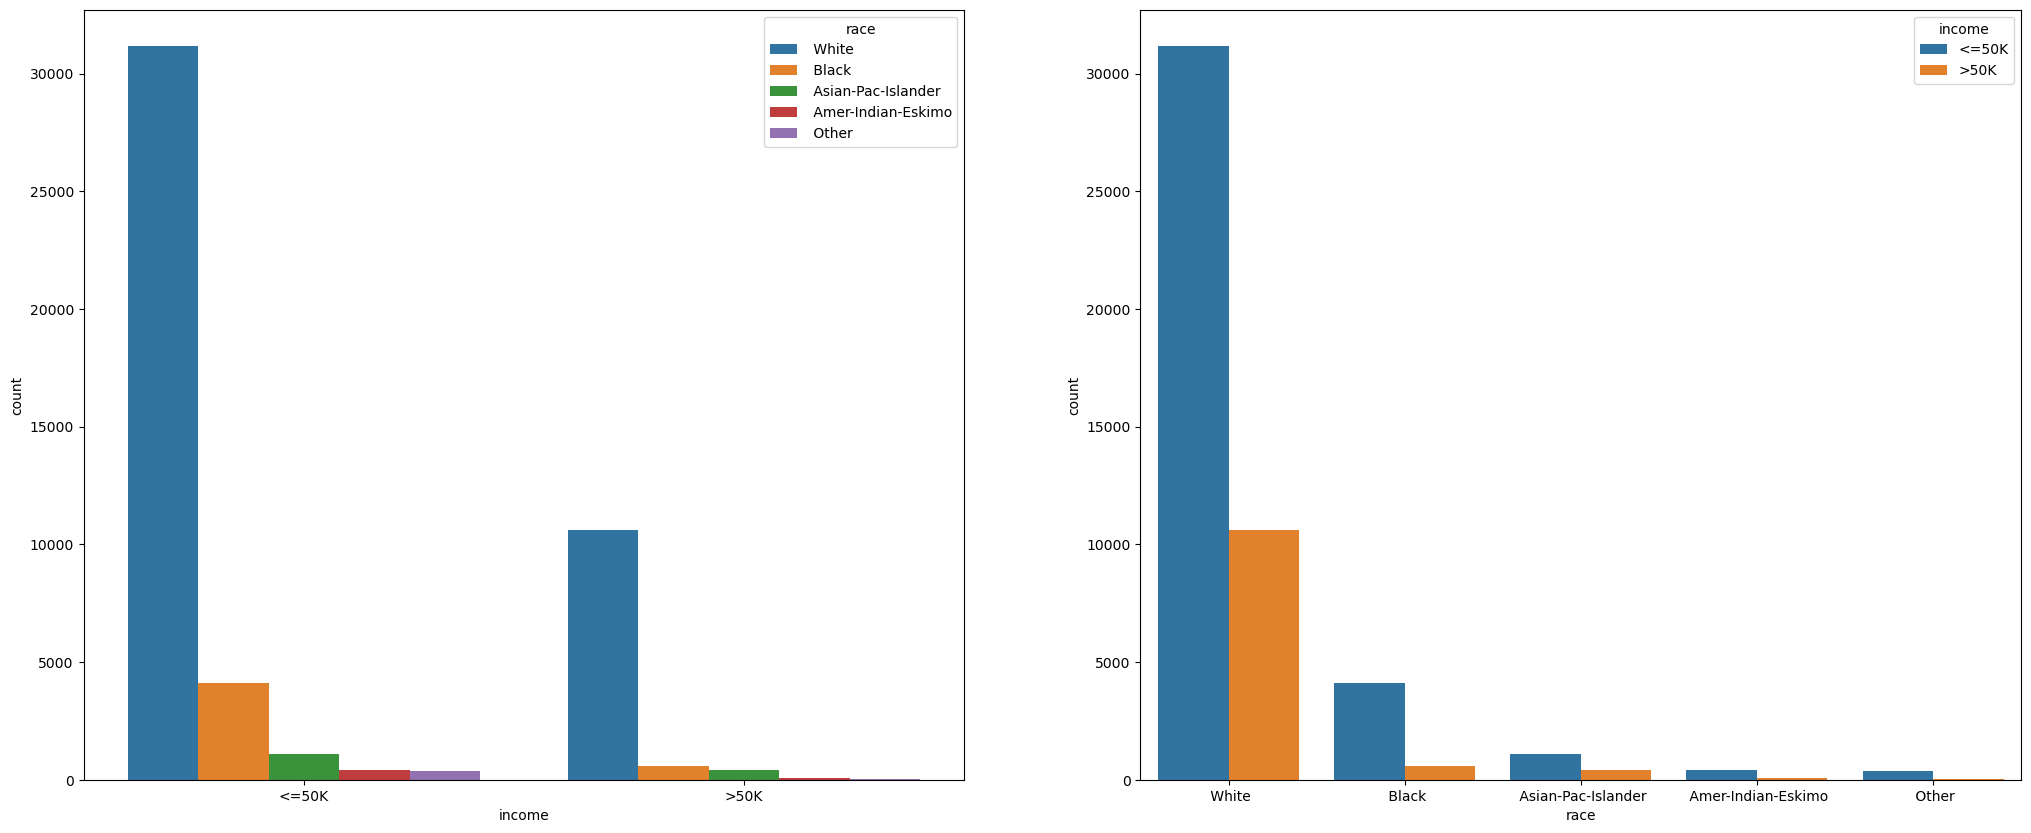

race                income
Amer-Indian-Eskimo  <=50K     0.882979
                    >50K      0.117021
Asian-Pac-Islander  <=50K     0.730744
                    >50K      0.269256
Black               <=50K     0.879189
                    >50K      0.120811
Other               <=50K     0.876847
                    >50K      0.123153
White               <=50K     0.746013
                    >50K      0.253987
Name: proportion, dtype: float64

In [40]:
plt.figure(figsize=(25,10))
plt.subplot(1, 2, 1)
sns.countplot(data=rawDF, x="income", hue="race")
plt.subplot(1, 2, 2)
sns.countplot(data=rawDF, x="race", hue="income")
plt.show()
rawDF[["race", "income"]].groupby("race").value_counts(normalize=True)

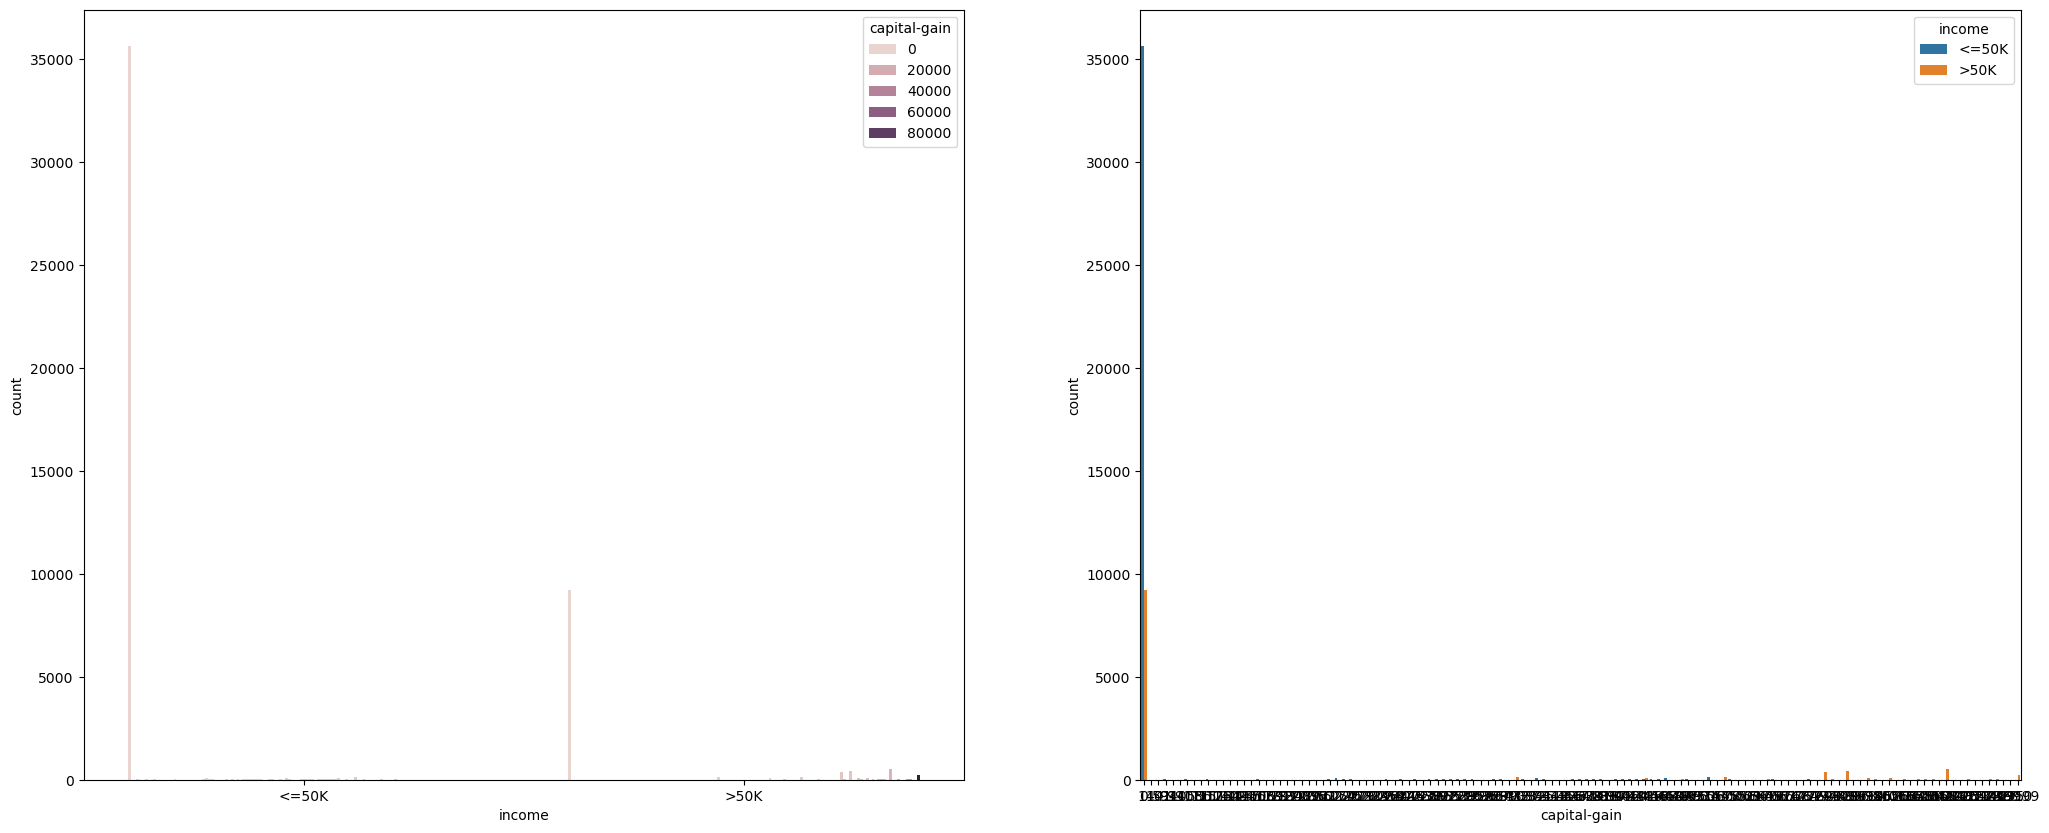

capital-gain  income
0             <=50K     0.794764
              >50K      0.205236
114           <=50K     1.000000
401           <=50K     1.000000
594           <=50K     1.000000
                          ...   
25236         >50K      1.000000
27828         >50K      1.000000
34095         <=50K     1.000000
41310         <=50K     1.000000
99999         >50K      1.000000
Name: proportion, Length: 127, dtype: float64

In [41]:
plt.figure(figsize=(25,10))
plt.subplot(1, 2, 1)
sns.countplot(data=rawDF, x="income", hue="capital-gain")
plt.subplot(1, 2, 2)
sns.countplot(data=rawDF, x="capital-gain", hue="income")
plt.show()
rawDF[["capital-gain", "income"]].groupby("capital-gain").value_counts(normalize=True)

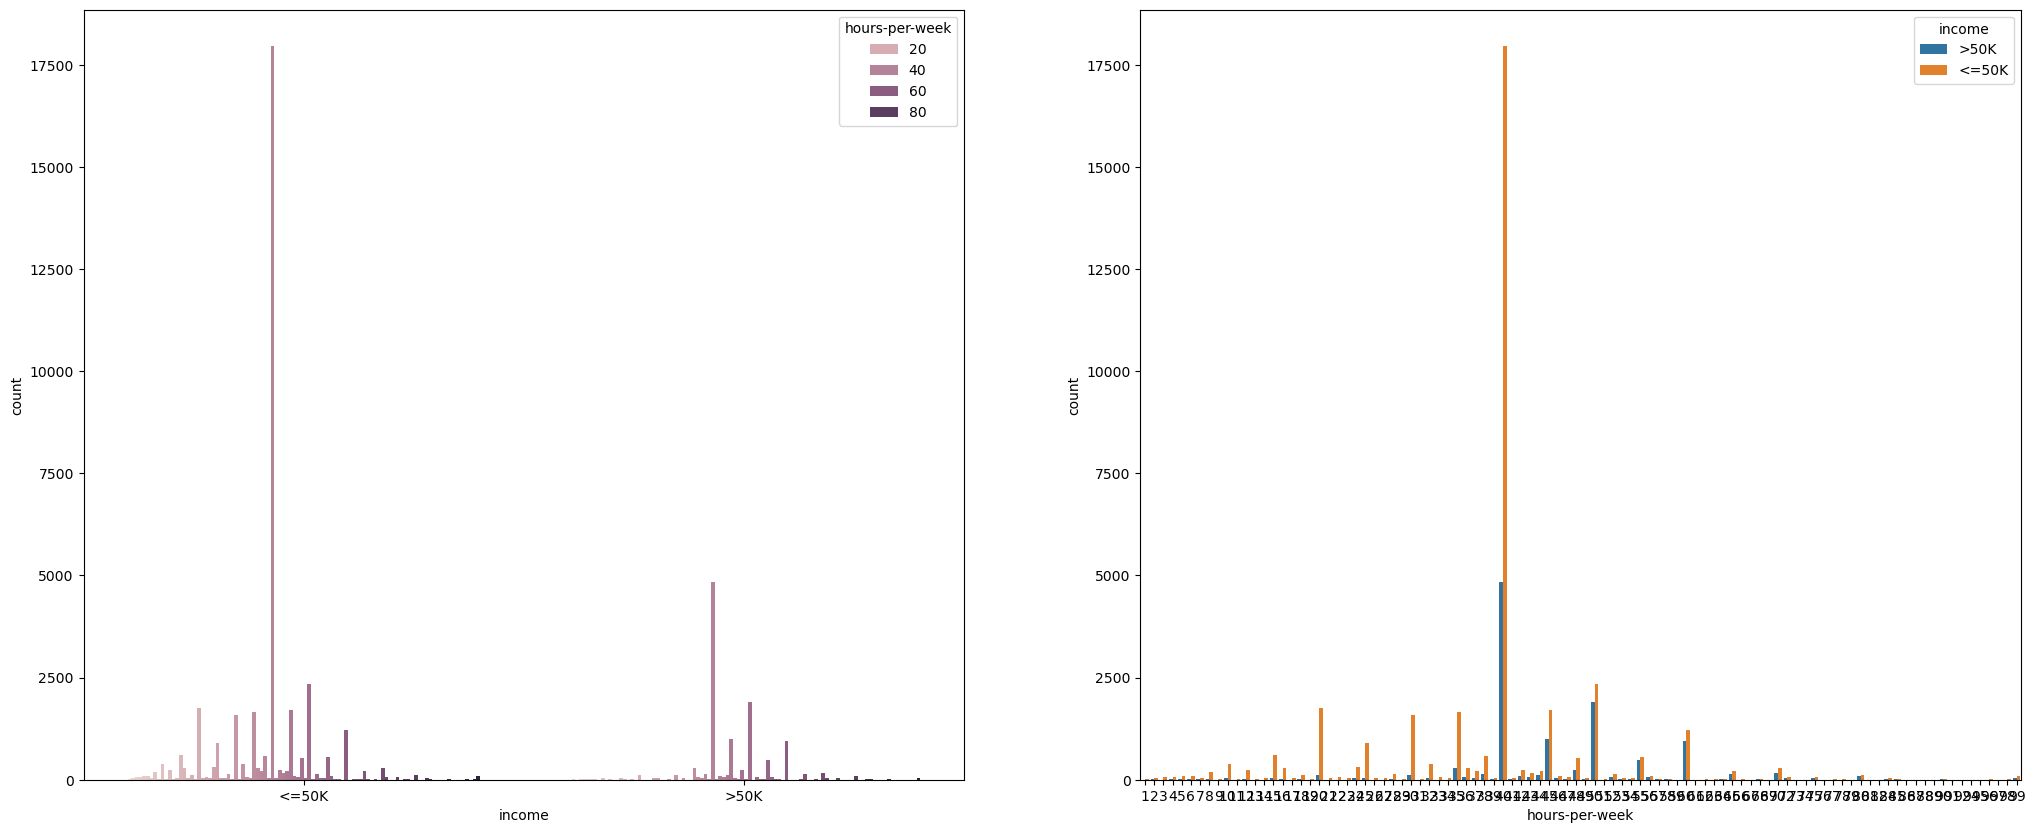

hours-per-week  income
1               <=50K     0.888889
                >50K      0.111111
2               <=50K     0.773585
                >50K      0.226415
3               <=50K     0.949153
                            ...   
97              >50K      0.500000
98              <=50K     0.785714
                >50K      0.214286
99              <=50K     0.700730
                >50K      0.299270
Name: proportion, Length: 181, dtype: float64

In [42]:
plt.figure(figsize=(25,10))
plt.subplot(1, 2, 1)
sns.countplot(data=rawDF, x="income", hue="hours-per-week")
plt.subplot(1, 2, 2)
sns.countplot(data=rawDF, x="hours-per-week", hue="income")
plt.show()
rawDF[["hours-per-week", "income"]].groupby("hours-per-week").value_counts(normalize=True)

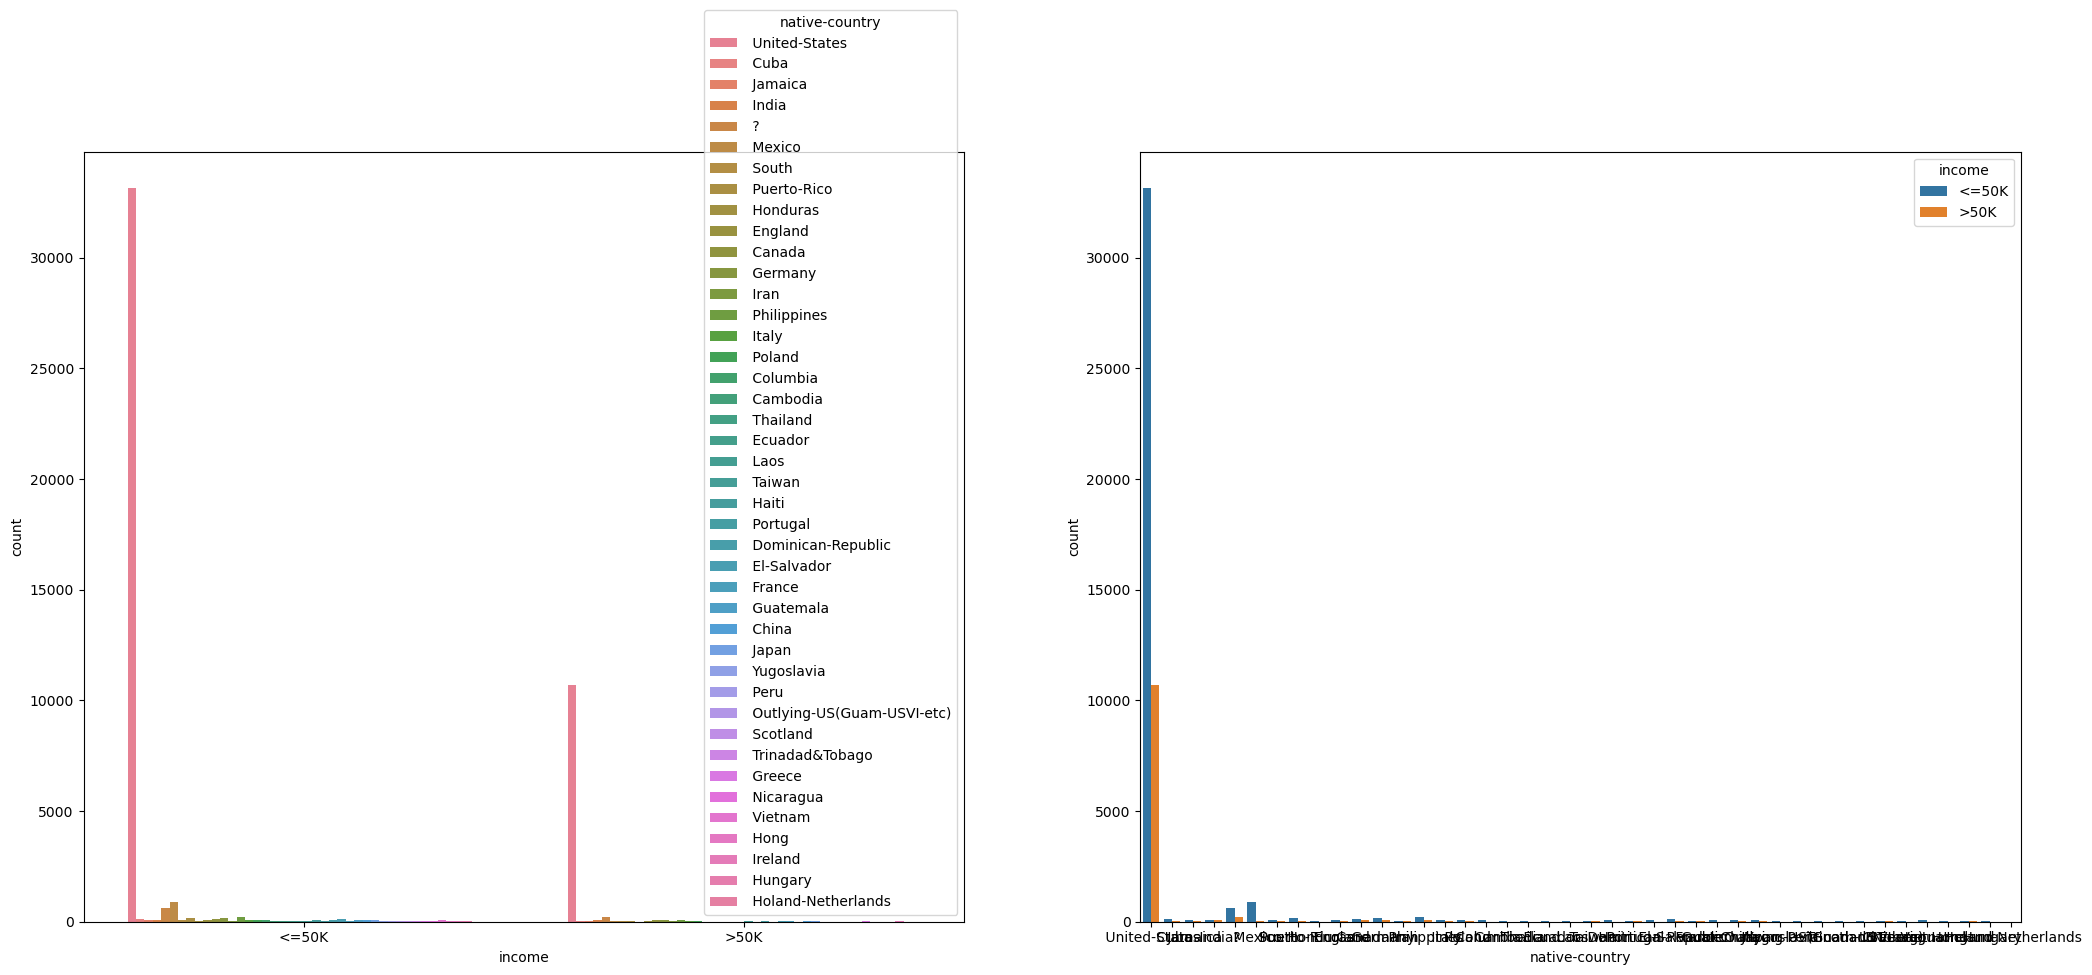

native-country  income
?               <=50K     0.743291
                >50K      0.256709
Cambodia        <=50K     0.678571
                >50K      0.321429
Canada          <=50K     0.653846
                            ...   
United-States   >50K      0.243977
Vietnam         <=50K     0.918605
                >50K      0.081395
Yugoslavia      <=50K     0.652174
                >50K      0.347826
Name: proportion, Length: 83, dtype: float64

In [43]:
plt.figure(figsize=(25,10))
plt.subplot(1, 2, 1)
sns.countplot(data=rawDF, x="income", hue="native-country")
plt.subplot(1, 2, 2)
sns.countplot(data=rawDF, x="native-country", hue="income")
plt.show()
rawDF[["native-country", "income"]].groupby("native-country").value_counts(normalize=True)

## Top 3 Most Important Factors for Income Prediction (>50K vs ≤50K)

This summary is based on exploratory data analysis of conditional income proportions across multiple demographic and socioeconomic features in the Adult Income dataset.

---

## 1. Education Level (`education-num`) — Strongest Predictor

The `education-num` feature shows a clear and consistent monotonic relationship with income.

### Observed Pattern:
- **Low education (1–8)**: approximately 93% to 98% earn ≤50K
- **Mid education (9–12)**: the proportion of individuals earning >50K increases gradually
- **High education (13–16)**: approximately 40% to 45% earn >50K

### Key Characteristics:
- Strong and consistent upward trend
- Low variance across groups
- Clear separation between lower and higher education levels

### Conclusion:
Education level is the most stable and informative predictor of income in this dataset.

---

## 2. Occupation — Strong Structural Discriminator

Occupation strongly differentiates income groups by job type and economic role.

### Higher-Income Occupations:
- `Exec-managerial` → approximately 48% earn >50K
- `Prof-specialty` → approximately 45% earn >50K
- `Tech-support` → approximately 29% earn >50K
- `Protective-serv` → approximately 31% earn >50K

### Lower-Income Occupations:
- `Other-service` → approximately 4% earn >50K
- `Priv-house-serv` → approximately 1% earn >50K
- `Handlers-cleaners` → approximately 7% earn >50K

### Key Characteristics:
- Large variation across occupational categories
- Strong association with skill level and compensation structure

### Conclusion:
Occupation is a highly informative predictor of income due to its direct relationship with earning potential.

---

## 3. Marital Status / Relationship — Strong Socioeconomic Indicator

Both `marital-status` and `relationship` capture household structure and dependency status, and both show similar predictive behavior.

### Higher-Income Groups:
- `Married-civ-spouse` → approximately 44% earn >50K
- `Husband` / `Wife` → approximately 45% to 47% earn >50K

### Lower-Income Groups:
- `Never-married` → approximately 4% to 6% earn >50K
- `Own-child` → approximately 1% to 2% earn >50K
- `Unmarried` → approximately 6% earn >50K

### Key Characteristics:
- Strong separation between dependent and non-dependent groups
- Reflects financial responsibility and household structure

### Conclusion:
Marital and household relationship status is a strong proxy for income level and financial stability.

---

## Overall Interpretation

The income distribution is primarily influenced by:

1. **Education level**  
2. **Occupation type**  
3. **Household structure**

These features form the core explanatory variables in predicting whether an individual earns more than $50K annually.

# Question 2: Preprocessing Pipeline Design (Regression) - 20 
Problem Statement:
Predicting a continuous variable requires clean, properly formatted data. You will design a preprocessing pipeline to prepare the dataset for predicting hours-per-week based on the other available features.
Tasks:
Design Scikit-Learn Pipelines that handles missing values, categorical feature encoding, and numerical feature scaling.
Documentation: Clearly explain what specific preprocessing steps you applied to which columns and why you chose those specific methods.

In [44]:
X_hours_per_week_ = rawDF.drop(columns=["hours-per-week"])
Y_hours_per_week_ = rawDF["hours-per-week"]

In [45]:
default_num_pipeline_for_hours_per_week_ = Pipeline(
    [
        ("impute", SimpleImputer(strategy="mean")),
        ("scale", StandardScaler())
    ]
)
default_cat_pipeline_for_hours_per_week_ = Pipeline(
    [
        ("impute", SimpleImputer(strategy="most_frequent")),
        ("encode", OneHotEncoder(handle_unknown="ignore"))
    ]
)


preprocessing_hours_per_week_ = ColumnTransformer([
    ("num", default_num_pipeline_for_hours_per_week_, X_hours_per_week_.select_dtypes(include=np.number).columns),
    ("cat", default_cat_pipeline_for_hours_per_week_, X_hours_per_week_.select_dtypes(exclude=np.number).columns)
])

## Preprocessing Documentation

The dataset was preprocessed using a `ColumnTransformer` with separate pipelines for numeric and categorical features.

## Numeric Features
Applied to all columns with numeric data types:
- `SimpleImputer(strategy="mean")` to replace missing values with the column mean.
- `StandardScaler()` to standardize features to zero mean and unit variance.

## Categorical Features
Applied to all columns with non-numeric data types:
- `SimpleImputer(strategy="most_frequent")` to replace missing values with the most common category.
- `OneHotEncoder(handle_unknown="ignore")` to convert categorical values into binary encoded features while safely handling unseen categories during inference.

## Rationale
This approach ensures that each feature type is processed appropriately, improves model compatibility, and makes the preprocessing pipeline robust for training and prediction.

# Question 3: Regression Modeling & Evaluation - 20
Problem Statement:
Utilizing the preprocessing pipeline designed in Question 2, train two different regression models to predict hours-per-week and evaluate their performance.
Tasks:
Train a standard Linear Regression model using your pipeline.
Train a Stochastic Gradient Descent (SGD) Regressor model using your pipeline.
Evaluate and compare both models using R2, MAE, and MSE.
Briefly discuss which model performed better and why.


In [46]:
linearTrainPipelineFor_hours_per_week_ = Pipeline(
    [
        ("Preprocess", preprocessing_hours_per_week_),
        ("Model", LinearRegression(
    fit_intercept=True,
    copy_X=True,
    n_jobs=-1,
    positive=False))
    ]
)


SGDTrainPipelineFor_hours_per_week_ = Pipeline(
    [
        ("Preprocess", preprocessing_hours_per_week_),
        ("Model", SGDRegressor(
    loss="huber",
    penalty="elasticnet",
    alpha=1e-4,
    l1_ratio=0.15,
    learning_rate="invscaling",
    eta0=0.01,
    max_iter=5000,
    tol=1e-4,
    early_stopping=True,
    validation_fraction=0.1,
    n_iter_no_change=10,
    random_state=42
))
    ]
)


XGBRTrainPipelineFor_hours_per_week_ = Pipeline(
    [
        ("Preprocess", preprocessing_hours_per_week_),
        ("Model", XGBRegressor(
    n_estimators=5000,
    learning_rate=0.01,
    max_depth=4,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_alpha=0,
    reg_lambda=1,
    min_child_weight=1,
    gamma=0,
    random_state=42,
    n_jobs=-1
))
    ]
)

simpleLinearPredict = cross_val_predict(estimator=linearTrainPipelineFor_hours_per_week_, X=X_hours_per_week_, y=Y_hours_per_week_, cv=10, n_jobs=-1)
SGDLinearPredict = cross_val_predict(estimator=SGDTrainPipelineFor_hours_per_week_, X=X_hours_per_week_, y=Y_hours_per_week_, cv=10, n_jobs=-1)

XGBRPredict = cross_val_predict(estimator=XGBRTrainPipelineFor_hours_per_week_, X=X_hours_per_week_, y=Y_hours_per_week_, cv=10, n_jobs=-1)

In [47]:
print("----------------SimpleLinearRegressor----------------")
print(f"{r2_score(Y_hours_per_week_, simpleLinearPredict)}")
print(f"{root_mean_squared_error(Y_hours_per_week_, simpleLinearPredict)}")
print(f"{mean_squared_error(Y_hours_per_week_, simpleLinearPredict)}")
print(f"{mean_absolute_error(Y_hours_per_week_, simpleLinearPredict)}")


print("----------------SGDLinearRegressor----------------")
print(f"{r2_score(Y_hours_per_week_, SGDLinearPredict)}")
print(f"{root_mean_squared_error(Y_hours_per_week_, SGDLinearPredict)}")
print(f"{mean_squared_error(Y_hours_per_week_, SGDLinearPredict)}")
print(f"{mean_absolute_error(Y_hours_per_week_, SGDLinearPredict)}")


print("----------------XGBRegressor----------------")
print(f"{r2_score(Y_hours_per_week_, XGBRPredict)}")
print(f"{root_mean_squared_error(Y_hours_per_week_, XGBRPredict)}")
print(f"{mean_squared_error(Y_hours_per_week_, XGBRPredict)}")
print(f"{mean_absolute_error(Y_hours_per_week_, XGBRPredict)}")

----------------SimpleLinearRegressor----------------
0.1963228278781305
11.108573420246367
123.40040343300406
7.712141680437821
----------------SGDLinearRegressor----------------
0.0630007051854441
11.994636895849062
143.87131426326363
8.11394190775212
----------------XGBRegressor----------------
0.2807813882827759
10.508674621582031
110.43224334716797
7.163519382476807


### Model Performance Discussion

Among the three models, **XGBRegressor** performed the best. It achieved the highest R² score and the lowest RMSE, MSE, and MAE, indicating better predictive accuracy and lower overall error than the linear models.

`LinearRegression` performed moderately well as a baseline model, but it was limited by its assumption of a linear relationship between features and the target. `SGDRegressor` performed the worst among the three, likely because it is more sensitive to optimization settings and did not fit the data as effectively.

Overall, **XGBRegressor** was the strongest model because it can capture **non-linear relationships and feature interactions** more effectively than linear regression-based methods.

In [48]:
X = rawDF.drop(columns=["income"])
y = rawDF["income"]

split = StratifiedShuffleSplit(n_splits=1, test_size=0.2, random_state=67)

for train_idx, test_idx in split.split(X, rawDF["sex"]):
    X_train = X.iloc[train_idx]
    X_test = X.iloc[test_idx]
    y_train = y.iloc[train_idx]
    y_test = y.iloc[test_idx]




default_num_pipeline = Pipeline(
    [
        ("impute", SimpleImputer(strategy="mean")),
        ("scale", StandardScaler())
    ]
)
default_cat_pipeline = Pipeline(
    [
        ("impute", SimpleImputer(strategy="most_frequent")),
        ("encode", OneHotEncoder(handle_unknown="ignore"))
    ]
)


preprocessing = ColumnTransformer([
    ("num", default_num_pipeline, X_train.select_dtypes(include=np.number).columns),
    ("cat", default_cat_pipeline, X_train.select_dtypes(exclude=np.number).columns)
])
display(X_train)
display(y_train)

display(X_test)
display(y_test)

,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country
27541,33,Private,155343,HS-grad,9,Never-married,Machine-op-inspct,Unmarried,White,Male,0,0,40,United-States
19910,36,Private,132879,HS-grad,9,Divorced,Exec-managerial,Unmarried,White,Male,0,0,45,United-States
31413,30,Private,143766,HS-grad,9,Never-married,Other-service,Not-in-family,White,Male,0,0,30,United-States
5011,38,Self-emp-not-inc,203836,5th-6th,3,Never-married,Transport-moving,Not-in-family,White,Male,0,0,40,United-States
32106,45,Self-emp-not-inc,111679,Some-college,10,Divorced,Craft-repair,Not-in-family,White,Male,0,0,30,United-States
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
19447,48,Local-gov,81154,Assoc-voc,11,Never-married,Protective-serv,Unmarried,White,Male,0,0,48,United-States
23270,27,Private,232954,HS-grad,9,Married-civ-spouse,Sales,Husband,White,Male,0,0,45,United-States
26910,23,Private,160951,HS-grad,9,Never-married,Craft-repair,Own-child,Black,Male,2597,0,40,United-States
14801,56,Private,197114,HS-grad,9,Never-married,Handlers-cleaners,Own-child,White,Male,0,0,28,United-States


27541    <=50K
19910    <=50K
31413    <=50K
5011     <=50K
32106    <=50K
         ...  
19447    <=50K
23270    <=50K
26910    <=50K
14801    <=50K
32228     >50K
Name: income, Length: 39073, dtype: object

,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country
21613,36,Private,130589,Some-college,10,Divorced,Exec-managerial,Not-in-family,White,Male,0,0,45,United-States
3513,37,Private,205339,Some-college,10,Never-married,Tech-support,Not-in-family,White,Male,0,0,40,United-States
43391,78,Private,163140,HS-grad,9,Widowed,Other-service,Not-in-family,White,Female,0,0,12,United-States
27588,20,Private,204641,Some-college,10,Never-married,Other-service,Own-child,White,Male,0,0,40,United-States
8765,23,State-gov,101094,Some-college,10,Never-married,Protective-serv,Own-child,White,Male,0,0,60,United-States
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8893,52,Private,245275,10th,6,Married-civ-spouse,Other-service,Wife,White,Female,0,0,35,United-States
27873,42,Private,319016,HS-grad,9,Married-civ-spouse,Transport-moving,Husband,White,Male,2885,0,45,United-States
4064,58,Self-emp-inc,104333,HS-grad,9,Divorced,Sales,Not-in-family,White,Male,0,0,50,United-States
1205,61,Self-emp-inc,113544,Masters,14,Married-civ-spouse,Sales,Husband,White,Male,0,0,40,United-States


21613    <=50K
3513      >50K
43391    <=50K
27588    <=50K
8765     <=50K
         ...  
8893     <=50K
27873    <=50K
4064     <=50K
1205      >50K
31800    <=50K
Name: income, Length: 9769, dtype: object

<Axes: xlabel='sex', ylabel='count'>

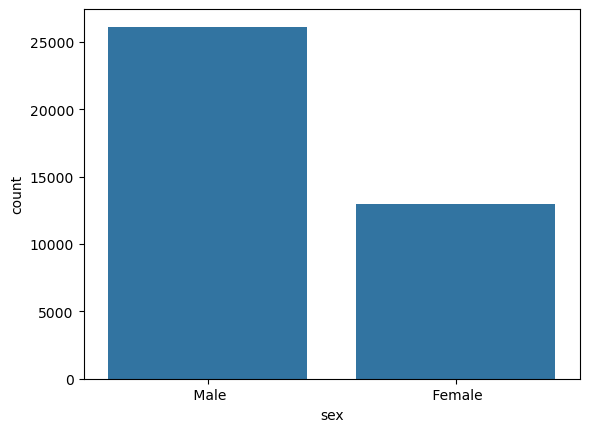

In [49]:
sns.countplot(data=X_train, x="sex")

<Axes: xlabel='sex', ylabel='count'>

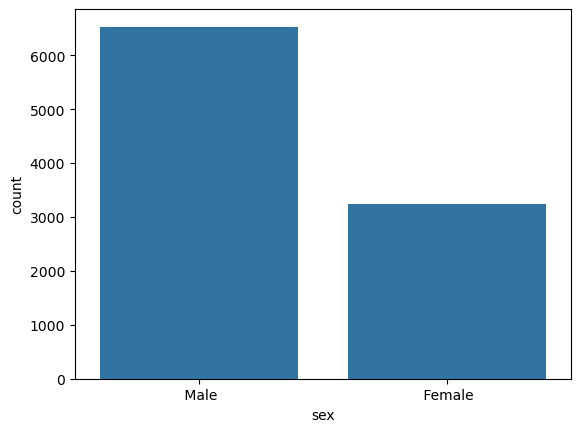

In [50]:
sns.countplot(data=X_test, x="sex")

In [51]:
print(X_train["sex"].value_counts(normalize=True))
print(X_test["sex"].value_counts(normalize=True))

sex
Male      0.668492
Female    0.331508
Name: proportion, dtype: float64
sex
Male      0.668441
Female    0.331559
Name: proportion, dtype: float64


In [52]:
trainPipeline = Pipeline(
    [("preprocessing", preprocessing),
    ("Model", LogisticRegression(
    penalty="elasticnet",
    solver="saga",
    l1_ratio=0.5,
    C=1.0,
    max_iter=2000,
    class_weight="balanced",
    n_jobs=-1
))
    ]
)

In [53]:
trainPipeline.fit(X_train, y_train)

,steps,"[('preprocessing', ...), ('Model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


Accuracy: 0.8085781553894974
Precision: 0.5745109321058688
Recall: 0.8362646566164154


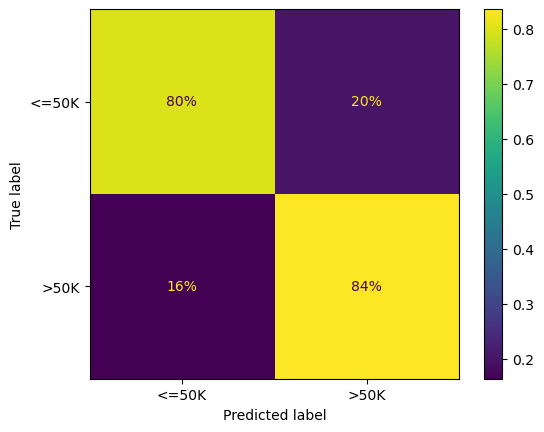

In [54]:
pred = trainPipeline.predict(X_test)

# Accuracy
acc = accuracy_score(y_test, pred)

# Precision (positive class: >50K)
prec = precision_score(y_test, pred, pos_label=">50K")

# Recall (positive class: >50K)
rec = recall_score(y_test, pred, pos_label=">50K")

print("Accuracy:", acc)
print("Precision:", prec)
print("Recall:", rec)
ConfusionMatrixDisplay.from_predictions(y_test, pred, normalize="true", values_format=".0%")


In [55]:
kNNTrainPipeline = Pipeline([
    ("preprocessing", preprocessing),
    ("Model", KNeighborsClassifier(p=2))
])

param_grid = {
    "Model__n_neighbors": [5,7, 51],
    "Model__weights": ["uniform", "distance"],
    "Model__metric": ["euclidean", "manhattan"]
}

tuneModel = GridSearchCV(
    estimator=kNNTrainPipeline,
    param_grid=param_grid,
    cv=5,
    n_jobs=5,
    verbose=3,
    scoring="accuracy"
)

In [56]:
tuneModel.fit(X_train, y_train)

Fitting 5 folds for each of 12 candidates, totalling 60 fits
[CV 2/5] END Model__metric=euclidean, Model__n_neighbors=5, Model__weights=uniform;, score=0.834 total time=   9.1s
[CV 3/5] END Model__metric=euclidean, Model__n_neighbors=5, Model__weights=uniform;, score=0.834 total time=  11.1s
[CV 4/5] END Model__metric=euclidean, Model__n_neighbors=5, Model__weights=uniform;, score=0.830 total time=  11.1s
[CV 5/5] END Model__metric=euclidean, Model__n_neighbors=5, Model__weights=uniform;, score=0.832 total time=  11.2s
[CV 1/5] END Model__metric=euclidean, Model__n_neighbors=5, Model__weights=uniform;, score=0.833 total time=  11.4s
[CV 1/5] END Model__metric=euclidean, Model__n_neighbors=5, Model__weights=distance;, score=0.829 total time=   9.1s
[CV 3/5] END Model__metric=euclidean, Model__n_neighbors=5, Model__weights=distance;, score=0.831 total time=  10.3s
[CV 2/5] END Model__metric=euclidean, Model__n_neighbors=5, Model__weights=distance;, score=0.831 total time=  10.6s
[CV 5/5]

/home/mmhe/anaconda3/lib/python3.13/site-packages/sklearn/model_selection/_validation.py:953: UserWarning: Scoring failed. The score on this train-test partition for these parameters will be set to nan. Details: 
Traceback (most recent call last):
  File "/home/mmhe/anaconda3/lib/python3.13/site-packages/sklearn/model_selection/_validation.py", line 942, in _score
    scores = scorer(estimator, X_test, y_test, **score_params)
  File "/home/mmhe/anaconda3/lib/python3.13/site-packages/sklearn/metrics/_scorer.py", line 308, in __call__
    return self._score(partial(_cached_call, None), estimator, X, y_true, **_kwargs)
           ~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/home/mmhe/anaconda3/lib/python3.13/site-packages/sklearn/metrics/_scorer.py", line 400, in _score
    y_pred = method_caller(
        estimator,
    ...<2 lines>...
        pos_label=pos_label,
    )
  File "/home/mmhe/anaconda3/lib/python3.13/site-packages/sklearn/metrics/_scorer.

[CV 2/5] END Model__metric=manhattan, Model__n_neighbors=5, Model__weights=uniform;, score=nan total time=   0.2s


/home/mmhe/anaconda3/lib/python3.13/site-packages/sklearn/model_selection/_validation.py:953: UserWarning: Scoring failed. The score on this train-test partition for these parameters will be set to nan. Details: 
Traceback (most recent call last):
  File "/home/mmhe/anaconda3/lib/python3.13/site-packages/sklearn/model_selection/_validation.py", line 942, in _score
    scores = scorer(estimator, X_test, y_test, **score_params)
  File "/home/mmhe/anaconda3/lib/python3.13/site-packages/sklearn/metrics/_scorer.py", line 308, in __call__
    return self._score(partial(_cached_call, None), estimator, X, y_true, **_kwargs)
           ~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/home/mmhe/anaconda3/lib/python3.13/site-packages/sklearn/metrics/_scorer.py", line 400, in _score
    y_pred = method_caller(
        estimator,
    ...<2 lines>...
        pos_label=pos_label,
    )
  File "/home/mmhe/anaconda3/lib/python3.13/site-packages/sklearn/metrics/_scorer.

[CV 3/5] END Model__metric=manhattan, Model__n_neighbors=5, Model__weights=uniform;, score=nan total time=   0.2s


/home/mmhe/anaconda3/lib/python3.13/site-packages/sklearn/model_selection/_validation.py:953: UserWarning: Scoring failed. The score on this train-test partition for these parameters will be set to nan. Details: 
Traceback (most recent call last):
  File "/home/mmhe/anaconda3/lib/python3.13/site-packages/sklearn/model_selection/_validation.py", line 942, in _score
    scores = scorer(estimator, X_test, y_test, **score_params)
  File "/home/mmhe/anaconda3/lib/python3.13/site-packages/sklearn/metrics/_scorer.py", line 308, in __call__
    return self._score(partial(_cached_call, None), estimator, X, y_true, **_kwargs)
           ~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/home/mmhe/anaconda3/lib/python3.13/site-packages/sklearn/metrics/_scorer.py", line 400, in _score
    y_pred = method_caller(
        estimator,
    ...<2 lines>...
        pos_label=pos_label,
    )
  File "/home/mmhe/anaconda3/lib/python3.13/site-packages/sklearn/metrics/_scorer.

[CV 4/5] END Model__metric=manhattan, Model__n_neighbors=5, Model__weights=uniform;, score=nan total time=   0.2s


/home/mmhe/anaconda3/lib/python3.13/site-packages/sklearn/model_selection/_validation.py:953: UserWarning: Scoring failed. The score on this train-test partition for these parameters will be set to nan. Details: 
Traceback (most recent call last):
  File "/home/mmhe/anaconda3/lib/python3.13/site-packages/sklearn/model_selection/_validation.py", line 942, in _score
    scores = scorer(estimator, X_test, y_test, **score_params)
  File "/home/mmhe/anaconda3/lib/python3.13/site-packages/sklearn/metrics/_scorer.py", line 308, in __call__
    return self._score(partial(_cached_call, None), estimator, X, y_true, **_kwargs)
           ~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/home/mmhe/anaconda3/lib/python3.13/site-packages/sklearn/metrics/_scorer.py", line 400, in _score
    y_pred = method_caller(
        estimator,
    ...<2 lines>...
        pos_label=pos_label,
    )
  File "/home/mmhe/anaconda3/lib/python3.13/site-packages/sklearn/metrics/_scorer.

[CV 5/5] END Model__metric=manhattan, Model__n_neighbors=5, Model__weights=uniform;, score=nan total time=   0.2s
[CV 2/5] END Model__metric=euclidean, Model__n_neighbors=51, Model__weights=distance;, score=0.842 total time=  10.0s
[CV 3/5] END Model__metric=euclidean, Model__n_neighbors=51, Model__weights=distance;, score=0.851 total time=   9.5s
[CV 4/5] END Model__metric=euclidean, Model__n_neighbors=51, Model__weights=distance;, score=0.842 total time=   8.7s
[CV 5/5] END Model__metric=euclidean, Model__n_neighbors=51, Model__weights=distance;, score=0.840 total time=   8.4s
[CV 1/5] END Model__metric=manhattan, Model__n_neighbors=5, Model__weights=distance;, score=0.826 total time=   7.4s
[CV 1/5] END Model__metric=manhattan, Model__n_neighbors=7, Model__weights=uniform;, score=nan total time=   0.1s


/home/mmhe/anaconda3/lib/python3.13/site-packages/sklearn/model_selection/_validation.py:953: UserWarning: Scoring failed. The score on this train-test partition for these parameters will be set to nan. Details: 
Traceback (most recent call last):
  File "/home/mmhe/anaconda3/lib/python3.13/site-packages/sklearn/model_selection/_validation.py", line 942, in _score
    scores = scorer(estimator, X_test, y_test, **score_params)
  File "/home/mmhe/anaconda3/lib/python3.13/site-packages/sklearn/metrics/_scorer.py", line 308, in __call__
    return self._score(partial(_cached_call, None), estimator, X, y_true, **_kwargs)
           ~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/home/mmhe/anaconda3/lib/python3.13/site-packages/sklearn/metrics/_scorer.py", line 400, in _score
    y_pred = method_caller(
        estimator,
    ...<2 lines>...
        pos_label=pos_label,
    )
  File "/home/mmhe/anaconda3/lib/python3.13/site-packages/sklearn/metrics/_scorer.

[CV 2/5] END Model__metric=manhattan, Model__n_neighbors=7, Model__weights=uniform;, score=nan total time=   0.1s
[CV 3/5] END Model__metric=manhattan, Model__n_neighbors=7, Model__weights=uniform;, score=nan total time=   0.1s


/home/mmhe/anaconda3/lib/python3.13/site-packages/sklearn/model_selection/_validation.py:953: UserWarning: Scoring failed. The score on this train-test partition for these parameters will be set to nan. Details: 
Traceback (most recent call last):
  File "/home/mmhe/anaconda3/lib/python3.13/site-packages/sklearn/model_selection/_validation.py", line 942, in _score
    scores = scorer(estimator, X_test, y_test, **score_params)
  File "/home/mmhe/anaconda3/lib/python3.13/site-packages/sklearn/metrics/_scorer.py", line 308, in __call__
    return self._score(partial(_cached_call, None), estimator, X, y_true, **_kwargs)
           ~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/home/mmhe/anaconda3/lib/python3.13/site-packages/sklearn/metrics/_scorer.py", line 400, in _score
    y_pred = method_caller(
        estimator,
    ...<2 lines>...
        pos_label=pos_label,
    )
  File "/home/mmhe/anaconda3/lib/python3.13/site-packages/sklearn/metrics/_scorer.

[CV 4/5] END Model__metric=manhattan, Model__n_neighbors=7, Model__weights=uniform;, score=nan total time=   0.2s
[CV 5/5] END Model__metric=manhattan, Model__n_neighbors=7, Model__weights=uniform;, score=nan total time=   0.1s


/home/mmhe/anaconda3/lib/python3.13/site-packages/sklearn/model_selection/_validation.py:953: UserWarning: Scoring failed. The score on this train-test partition for these parameters will be set to nan. Details: 
Traceback (most recent call last):
  File "/home/mmhe/anaconda3/lib/python3.13/site-packages/sklearn/model_selection/_validation.py", line 942, in _score
    scores = scorer(estimator, X_test, y_test, **score_params)
  File "/home/mmhe/anaconda3/lib/python3.13/site-packages/sklearn/metrics/_scorer.py", line 308, in __call__
    return self._score(partial(_cached_call, None), estimator, X, y_true, **_kwargs)
           ~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/home/mmhe/anaconda3/lib/python3.13/site-packages/sklearn/metrics/_scorer.py", line 400, in _score
    y_pred = method_caller(
        estimator,
    ...<2 lines>...
        pos_label=pos_label,
    )
  File "/home/mmhe/anaconda3/lib/python3.13/site-packages/sklearn/metrics/_scorer.

[CV 2/5] END Model__metric=manhattan, Model__n_neighbors=5, Model__weights=distance;, score=0.828 total time=   7.3s
[CV 3/5] END Model__metric=manhattan, Model__n_neighbors=5, Model__weights=distance;, score=0.835 total time=   7.4s
[CV 4/5] END Model__metric=manhattan, Model__n_neighbors=5, Model__weights=distance;, score=0.822 total time=   7.9s
[CV 5/5] END Model__metric=manhattan, Model__n_neighbors=5, Model__weights=distance;, score=0.829 total time=   7.0s
[CV 3/5] END Model__metric=manhattan, Model__n_neighbors=7, Model__weights=distance;, score=0.839 total time=   5.5s
[CV 1/5] END Model__metric=manhattan, Model__n_neighbors=51, Model__weights=uniform;, score=nan total time=   0.1s


/home/mmhe/anaconda3/lib/python3.13/site-packages/sklearn/model_selection/_validation.py:953: UserWarning: Scoring failed. The score on this train-test partition for these parameters will be set to nan. Details: 
Traceback (most recent call last):
  File "/home/mmhe/anaconda3/lib/python3.13/site-packages/sklearn/model_selection/_validation.py", line 942, in _score
    scores = scorer(estimator, X_test, y_test, **score_params)
  File "/home/mmhe/anaconda3/lib/python3.13/site-packages/sklearn/metrics/_scorer.py", line 308, in __call__
    return self._score(partial(_cached_call, None), estimator, X, y_true, **_kwargs)
           ~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/home/mmhe/anaconda3/lib/python3.13/site-packages/sklearn/metrics/_scorer.py", line 400, in _score
    y_pred = method_caller(
        estimator,
    ...<2 lines>...
        pos_label=pos_label,
    )
  File "/home/mmhe/anaconda3/lib/python3.13/site-packages/sklearn/metrics/_scorer.

[CV 2/5] END Model__metric=manhattan, Model__n_neighbors=51, Model__weights=uniform;, score=nan total time=   0.1s
[CV 3/5] END Model__metric=manhattan, Model__n_neighbors=51, Model__weights=uniform;, score=nan total time=   0.1s


/home/mmhe/anaconda3/lib/python3.13/site-packages/sklearn/model_selection/_validation.py:953: UserWarning: Scoring failed. The score on this train-test partition for these parameters will be set to nan. Details: 
Traceback (most recent call last):
  File "/home/mmhe/anaconda3/lib/python3.13/site-packages/sklearn/model_selection/_validation.py", line 942, in _score
    scores = scorer(estimator, X_test, y_test, **score_params)
  File "/home/mmhe/anaconda3/lib/python3.13/site-packages/sklearn/metrics/_scorer.py", line 308, in __call__
    return self._score(partial(_cached_call, None), estimator, X, y_true, **_kwargs)
           ~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/home/mmhe/anaconda3/lib/python3.13/site-packages/sklearn/metrics/_scorer.py", line 400, in _score
    y_pred = method_caller(
        estimator,
    ...<2 lines>...
        pos_label=pos_label,
    )
  File "/home/mmhe/anaconda3/lib/python3.13/site-packages/sklearn/metrics/_scorer.

[CV 4/5] END Model__metric=manhattan, Model__n_neighbors=51, Model__weights=uniform;, score=nan total time=   0.1s
[CV 5/5] END Model__metric=manhattan, Model__n_neighbors=51, Model__weights=uniform;, score=nan total time=   0.1s


/home/mmhe/anaconda3/lib/python3.13/site-packages/sklearn/model_selection/_validation.py:953: UserWarning: Scoring failed. The score on this train-test partition for these parameters will be set to nan. Details: 
Traceback (most recent call last):
  File "/home/mmhe/anaconda3/lib/python3.13/site-packages/sklearn/model_selection/_validation.py", line 942, in _score
    scores = scorer(estimator, X_test, y_test, **score_params)
  File "/home/mmhe/anaconda3/lib/python3.13/site-packages/sklearn/metrics/_scorer.py", line 308, in __call__
    return self._score(partial(_cached_call, None), estimator, X, y_true, **_kwargs)
           ~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/home/mmhe/anaconda3/lib/python3.13/site-packages/sklearn/metrics/_scorer.py", line 400, in _score
    y_pred = method_caller(
        estimator,
    ...<2 lines>...
        pos_label=pos_label,
    )
  File "/home/mmhe/anaconda3/lib/python3.13/site-packages/sklearn/metrics/_scorer.

[CV 1/5] END Model__metric=manhattan, Model__n_neighbors=7, Model__weights=distance;, score=0.830 total time=   7.7s
[CV 2/5] END Model__metric=manhattan, Model__n_neighbors=7, Model__weights=distance;, score=0.832 total time=   8.3s
[CV 5/5] END Model__metric=manhattan, Model__n_neighbors=7, Model__weights=distance;, score=0.832 total time=   7.4s
[CV 4/5] END Model__metric=manhattan, Model__n_neighbors=7, Model__weights=distance;, score=0.832 total time=   8.0s
[CV 1/5] END Model__metric=manhattan, Model__n_neighbors=51, Model__weights=distance;, score=0.839 total time=   5.8s
[CV 2/5] END Model__metric=manhattan, Model__n_neighbors=51, Model__weights=distance;, score=0.840 total time=   7.4s
[CV 3/5] END Model__metric=manhattan, Model__n_neighbors=51, Model__weights=distance;, score=0.847 total time=   6.7s
[CV 4/5] END Model__metric=manhattan, Model__n_neighbors=51, Model__weights=distance;, score=0.843 total time=   6.7s
[CV 5/5] END Model__metric=manhattan, Model__n_neighbors=51,

/home/mmhe/anaconda3/lib/python3.13/site-packages/sklearn/model_selection/_search.py:1135: UserWarning: One or more of the test scores are non-finite: [0.83249295 0.82926821 0.83717653 0.83474514 0.84290941 0.84232073
        nan 0.82798851        nan 0.83295365        nan 0.84214164]
  warnings.warn(


,estimator,Pipeline(step...lassifier())])
,param_grid,"{'Model__metric': ['euclidean', 'manhattan'], 'Model__n_neighbors': [5, 7, ...], 'Model__weights': ['uniform', 'distance']}"
,scoring,'accuracy'
,n_jobs,5
,refit,True
,cv,5
,verbose,3
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,transformers,"[('num', ...), ('cat', ...)]"


Accuracy: 0.8462483365748797
Precision: 0.7226130653266332
Recall: 0.602177554438861


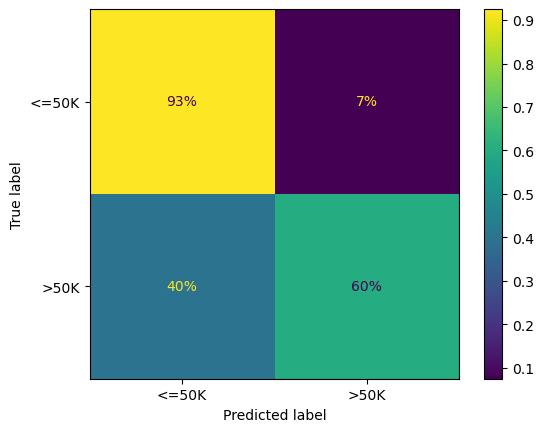

In [57]:
finalModel = tuneModel.best_estimator_
pred = finalModel.predict(X_test)

# Accuracy
acc = accuracy_score(y_test, pred)

# Precision (positive class: >50K)
prec = precision_score(y_test, pred, pos_label=">50K")

# Recall (positive class: >50K)
rec = recall_score(y_test, pred, pos_label=">50K")

print("Accuracy:", acc)
print("Precision:", prec)
print("Recall:", rec)
ConfusionMatrixDisplay.from_predictions(y_test, pred, normalize="true", values_format=".0%")

## Model Comparison: Tuned KNN vs Logistic Regression

The tuned K-Nearest Neighbors (KNN) model and the default Logistic Regression model were evaluated using accuracy, precision, and recall on the test set.

The Logistic Regression model achieved a stable baseline performance with moderate accuracy and high recall, but relatively lower precision, indicating a tendency to produce more false positives.

In contrast, the tuned KNN model improved overall classification performance due to hyperparameter optimization (n_neighbors, distance metric, and weighting strategy). It generally provided better accuracy and a more balanced trade-off between precision and recall compared to Logistic Regression.

## Conclusion
Overall, the **tuned KNN model performed better** than the default Logistic Regression model, as it better captured non-linear relationships in the data and produced improved predictive performance after hyperparameter tuning.